In [ ]:
# ── Config ──────────────────────────────────────────────────
import os

_OUT_BASE = '/Users/lee/Tracer/benchmark/methods/ours/output/FN1_01'
_RES_DIR  = '/Users/lee/Tracer/benchmark/results/ours'

SWC_FILE  = f'{_RES_DIR}/FN1_01.swc'        # 최종 결과 SWC (crop offset 보정 완료)
SOMA_NPZ  = f'{_OUT_BASE}/soma.npz'
STACK_TIF = f'{_OUT_BASE}/stack_preprocessed.tif'
PREP_NPZ  = f'{_OUT_BASE}/prep_riem.npz'

MIN_SEGMENT_LEN_UM = 15.0  # branch point 간 최소 segment 길이 — 짧은 spurious branch 제거

In [2]:
# ── Load ─────────────────────────────────────────────────────
import numpy as np
import plotly.graph_objects as go

swc_nodes = {}
with open(SWC_FILE) as f:
    for line in f:
        if line.startswith('#') or not line.strip(): continue
        p = line.split()
        nid = int(p[0])
        swc_nodes[nid] = dict(
            type=int(p[1]), x=float(p[2]), y=float(p[3]),
            z=float(p[4]), r=float(p[5]), parent=int(p[6])
        )

soma_data   = np.load(SOMA_NPZ)
sv_local    = soma_data['mesh_verts'].astype(np.float64)
sf          = soma_data['mesh_faces']
soma_cv     = soma_data['soma_centroid_vox']
voxel_iso_s = float(soma_data['voxel_iso'])

soma_global_um = soma_cv * voxel_iso_s
has_mesh = sv_local.shape[0] > 0
if has_mesh:
    sv_local_um    = sv_local * voxel_iso_s   # local voxel → µm
    mesh_local_ctr = sv_local_um.mean(axis=0)
    offset         = soma_global_um - mesh_local_ctr
    sv             = sv_local_um + offset
else:
    sv = np.zeros((0, 3), dtype=np.float64)
    sf = np.zeros((0, 3), dtype=np.int32)

print(f'SWC nodes  : {len(swc_nodes):,}')
print(f'Soma verts : {len(sv):,}  faces: {len(sf):,}  (mesh={"yes" if has_mesh else "sphere fallback"})')

SWC nodes  : 13,177
Soma verts : 26,492  faces: 52,980  (mesh=yes)


In [3]:
# ── Path length + branch order ─────────────────────────────────
from collections import defaultdict

def dist_um(a, b):
    return np.sqrt((a['x']-b['x'])**2+(a['y']-b['y'])**2+(a['z']-b['z'])**2)

children_map = defaultdict(list)
for nid, n in swc_nodes.items():
    if n['parent'] != -1:
        children_map[n['parent']].append(nid)

path_len = {1: 0.0}
queue    = [1]
while queue:
    cur = queue.pop(0)
    for ch in children_map.get(cur, []):
        path_len[ch] = path_len[cur] + dist_um(swc_nodes[cur], swc_nodes[ch])
        queue.append(ch)

branch_order = {1: 0}
queue = [1]
while queue:
    cur  = queue.pop(0)
    kids = children_map.get(cur, [])
    for ch in kids:
        branch_order[ch] = branch_order[cur] + (1 if len(kids) >= 2 else 0)
        queue.append(ch)

print(f'Max path length : {max(path_len.values()):.1f} µm')
print(f'Max branch order: {max(branch_order.values())}')

Max path length : 569.9 µm
Max branch order: 14


In [ ]:
# ── 3D visualization: branch order color ─────────────────────────────
from scipy.spatial import cKDTree

ORDER_COLORS = {
    0:'#888888', 1:'#FF4444', 2:'#FF8C00',
    3:'#FFD700', 4:'#44BB44', 5:'#4488FF',
}
def order_color(o): return ORDER_COLORS.get(min(o, 5), '#88AAFF')

if len(sv) > 0:
    soma_pts_xyz = np.column_stack([sv[:,2], sv[:,1], sv[:,0]])
    soma_tree    = cKDTree(soma_pts_xyz)
else:
    soma_pts_xyz = np.zeros((0, 3))
    soma_tree    = None

def soma_surface_pt(node):
    # soma mesh가 없으면 soma centroid 반환
    if soma_tree is None or len(soma_pts_xyz) == 0:
        sc = swc_nodes[1]
        return sc['x'], sc['y'], sc['z']
    _, idx = soma_tree.query([node['x'], node['y'], node['z']])
    return soma_pts_xyz[idx]

fig = go.Figure()

if len(sv) > 0:
    fig.add_trace(go.Mesh3d(
        x=sv[:,2], y=sv[:,1], z=sv[:,0],
        i=sf[:,0], j=sf[:,1], k=sf[:,2],
        color='#FF6B6B', opacity=0.9, flatshading=False,
        lighting=dict(ambient=0.5, diffuse=0.6, specular=0.3),
        lightposition=dict(x=2, y=2, z=5),
        name='Soma',
    ))
else:
    # sphere fallback
    sc = swc_nodes[1]; r = sc.get('r', soma_data.get('soma_equiv_r_um', 5.0) if hasattr(soma_data, 'get') else 5.0)
    try: r = float(soma_data['soma_equiv_r_um'])
    except: r = 5.0
    import numpy as _np
    phi = _np.linspace(0, _np.pi, 16); th = _np.linspace(0, 2*_np.pi, 32)
    PH, TH = _np.meshgrid(phi, th)
    sx2 = sc['x']+r*_np.sin(PH)*_np.cos(TH); sy2 = sc['y']+r*_np.sin(PH)*_np.sin(TH); sz2 = sc['z']+r*_np.cos(PH)
    fig.add_trace(go.Surface(x=sx2, y=sy2, z=sz2, colorscale=[[0,'#FF6B6B'],[1,'#FF6B6B']],
                              showscale=False, opacity=0.9, name='Soma'))

segs = defaultdict(lambda: {'x':[], 'y':[], 'z':[]})
for nid, n in swc_nodes.items():
    par_id = n['parent']
    if par_id == -1 or par_id not in swc_nodes: continue
    o = branch_order.get(nid, 0)
    if par_id == 1:
        sx, sy, sz = soma_surface_pt(n)
        segs[o]['x'] += [n['x'], sx, None]
        segs[o]['y'] += [n['y'], sy, None]
        segs[o]['z'] += [n['z'], sz, None]
    else:
        p = swc_nodes[par_id]
        segs[o]['x'] += [n['x'], p['x'], None]
        segs[o]['y'] += [n['y'], p['y'], None]
        segs[o]['z'] += [n['z'], p['z'], None]

ORDER_LABEL = {1:'1st (primary)',2:'2nd',3:'3rd',4:'4th'}
for o in sorted(segs.keys()):
    if o == 0: continue
    fig.add_trace(go.Scatter3d(
        x=segs[o]['x'], y=segs[o]['y'], z=segs[o]['z'],
        mode='lines',
        line=dict(color=order_color(o), width=2 if o<=2 else 1),
        name=ORDER_LABEL.get(o, f'{o}th'),
        opacity=0.9,
    ))

fig.update_layout(
    title=dict(text='Neuron Riemannian — branch order color', font=dict(color='white')),
    scene=dict(
        xaxis_title='X (µm)', yaxis_title='Y (µm)', zaxis_title='Z (µm)',
        bgcolor='#0a0a0a',
        xaxis=dict(backgroundcolor='#0a0a0a', gridcolor='#222', color='white'),
        yaxis=dict(backgroundcolor='#0a0a0a', gridcolor='#222', color='white'),
        zaxis=dict(backgroundcolor='#0a0a0a', gridcolor='#222', color='white'),
        aspectmode='data',
    ),
    paper_bgcolor='#111111', font_color='white',
    margin=dict(l=0, r=0, t=50, b=0),
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(30,30,30,0.8)'),
)
fig.show()

In [ ]:
# ── MIP overlay: XY / XZ / YZ ──────────────────────────────
import matplotlib.pyplot as plt
import tifffile
from matplotlib.lines import Line2D
import numpy as np

stack      = tifffile.imread(STACK_TIF).astype(np.float32)
stack_norm = stack / stack.max()

# stack_preprocessed.tif 은 step0 출력 (voxel_iso = preprocess_meta voxel_iso)
# prep_riem.npz voxel_iso 는 step1 DS 이후 해상도 → MIP에 쓰면 2배 어긋남
_meta       = np.load(PREP_NPZ.replace('prep_riem.npz', 'preprocess_meta.npz'))
voxel_iso   = float(_meta['voxel_iso'])          # step0 해상도 (예: 0.391µm)
voxel_iso_fmm = float(np.load(PREP_NPZ)['voxel_iso'])  # FMM 해상도 (예: 0.783µm)
print(f'stack voxel_iso={voxel_iso:.4f}µm  FMM voxel_iso={voxel_iso_fmm:.4f}µm')

mip_xy = stack_norm.max(axis=0)
mip_xz = stack_norm.max(axis=1)
mip_yz = stack_norm.max(axis=2)
del stack_norm

soma_n = swc_nodes[1]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
fig.patch.set_facecolor('#111111')

views = [
    (axes[0,0], axes[1,0], mip_xy, 'x', 'y', 'X (px)', 'Y (px)', 'XY'),
    (axes[0,1], axes[1,1], mip_xz, 'x', 'z', 'X (px)', 'Z (px)', 'XZ'),
    (axes[0,2], axes[1,2], mip_yz, 'y', 'z', 'Y (px)', 'Z (px)', 'YZ'),
]

for ax_raw, ax_swc, mip, hk, vk, hl, vl, title in views:
    for ax in (ax_raw, ax_swc):
        ax.imshow(mip, cmap='gray', origin='upper', vmin=0, vmax=0.8, aspect='equal')
        ax.axis('off')
    ax_raw.set_title(f'Raw MIP — {title}', color='white', fontsize=10)
    ax_swc.set_title(f'SWC overlay — {title}', color='white', fontsize=10)
    for nid, n in swc_nodes.items():
        if n['parent'] == -1 or n['parent'] not in swc_nodes: continue
        p = swc_nodes[n['parent']]
        o = branch_order.get(nid, 0)
        ax_swc.plot([n[hk]/voxel_iso, p[hk]/voxel_iso],
                    [n[vk]/voxel_iso, p[vk]/voxel_iso],
                    '-', color=order_color(o), lw=0.6, alpha=0.75)
    ax_swc.scatter([soma_n[hk]/voxel_iso], [soma_n[vk]/voxel_iso],
                   c='white', s=60, marker='*', zorder=5)

legend_items = [
    Line2D([0],[0], color='#FF4444', lw=2, label='1st'),
    Line2D([0],[0], color='#FF8C00', lw=2, label='2nd'),
    Line2D([0],[0], color='#FFD700', lw=2, label='3rd'),
    Line2D([0],[0], color='#44BB44', lw=2, label='4th'),
    Line2D([0],[0], color='#4488FF', lw=2, label='5th+'),
]
axes[1,2].legend(handles=legend_items, facecolor='#222',
                 labelcolor='white', fontsize=8, loc='upper right')
fig.suptitle('MIP overlay (Riemannian) — XY / XZ / YZ', color='white', fontsize=12)
plt.show()

In [6]:
# ── Loop detection ────────────────────────────────────────────────
import sys; sys.setrecursionlimit(100000)

visited, in_stack, loop_nodes = set(), set(), []

def dfs(node):
    visited.add(node); in_stack.add(node)
    for ch in children_map.get(node, []):
        if ch not in visited: dfs(ch)
        elif ch in in_stack: loop_nodes.append((node, ch))
    in_stack.discard(node)

dfs(1)
isolated = set(swc_nodes.keys()) - visited
print(f'Nodes total    : {len(swc_nodes):,}')
print(f'Nodes connected: {len(visited):,}')
print(f'Nodes isolated : {len(isolated):,}')
print(f'Loops detected : {len(loop_nodes)}')
if not loop_nodes: print('  → Tree structure OK')

Nodes total    : 13,177
Nodes connected: 13,177
Nodes isolated : 0
Loops detected : 0
  → Tree structure OK


In [ ]:
# ── Morphology ───────────────────────────────────────────────
from scipy.spatial import cKDTree

if len(sv) > 0:
    soma_pts_xyz = np.column_stack([sv[:,2], sv[:,1], sv[:,0]])
    soma_tree    = cKDTree(soma_pts_xyz)
else:
    soma_pts_xyz = np.zeros((0, 3))
    soma_tree    = None

soma_c = swc_nodes[1]

primary_correction = {}
for nid in children_map.get(1, []):
    n = swc_nodes[nid]
    if soma_tree is not None and len(soma_pts_xyz) > 0:
        _, idx = soma_tree.query([n['x'], n['y'], n['z']])
        sx, sy, sz = soma_pts_xyz[idx]
    else:
        sx, sy, sz = soma_c['x'], soma_c['y'], soma_c['z']
    primary_correction[nid] = np.sqrt(
        (sx-soma_c['x'])**2 + (sy-soma_c['y'])**2 + (sz-soma_c['z'])**2)

def get_primary_ancestor(nid):
    cur = nid
    while swc_nodes[cur]['parent'] not in (-1, 1):
        cur = swc_nodes[cur]['parent']
    return cur

def corrected_path_to_soma(tip_id):
    length, cur = 0.0, tip_id
    while swc_nodes[cur]['parent'] != -1:
        par = swc_nodes[cur]['parent']
        if par not in swc_nodes: break
        length += dist_um(swc_nodes[cur], swc_nodes[par])
        cur = par
    return max(length - primary_correction.get(get_primary_ancestor(tip_id), 0.0), 0.0)

connected   = visited
tips_ids    = [nid for nid in connected if not children_map.get(nid)]
branch_pts  = [nid for nid in connected if len(children_map.get(nid,[])) >= 2]
primary_ids = children_map.get(1, [])
tip_lengths = [corrected_path_to_soma(t) for t in tips_ids]

seg_raw          = sum(dist_um(swc_nodes[nid], swc_nodes[n['parent']])
                       for nid, n in swc_nodes.items()
                       if n['parent'] != -1 and n['parent'] in swc_nodes)
total_correction = sum(primary_correction.values())

d_prep    = np.load(PREP_NPZ)
soma_r_um = float(d_prep['soma_r_um'])

morph = dict(
    soma_radius_um   = soma_r_um,
    n_primary        = len(primary_ids),
    n_tips           = len(tips_ids),
    n_branch_pts     = len(branch_pts),
    max_branch_order = max(branch_order.values(), default=0),
    total_length_um  = seg_raw - total_correction,
    tip_dist_mean_um = float(np.mean(tip_lengths)) if tip_lengths else 0,
    tip_dist_max_um  = float(np.max(tip_lengths))  if tip_lengths else 0,
)

LABELS = {
    'soma_radius_um':'Soma radius','n_primary':'Primary branches',
    'n_tips':'Tips','n_branch_pts':'Branch points',
    'max_branch_order':'Max branch order','total_length_um':'Total length',
    'tip_dist_mean_um':'Tip dist mean','tip_dist_max_um':'Tip dist max',
}
print('='*48)
for k, v in morph.items():
    print(f'  {LABELS[k]:22s}: {v:.1f}')
print('='*48)

╔════════════════════════════════════════════════════╗
║                  MORPHOLOGY SUMMARY                ║
╠════════════════════════════════════════════════════╣
╠────────────────────────────────────────────────────╣
║  Soma                                              ║
╠────────────────────────────────────────────────────╣
║  Radius                    12.22             µm    ║
║  Volume (sphere)           7640              µm³   ║
╠────────────────────────────────────────────────────╣
║  Structure                                         ║
╠────────────────────────────────────────────────────╣
║  Primary branches          10                      ║
║  Branch points             184                     ║
║  Tips                      196                     ║
║  Total nodes               13,177                  ║
╠────────────────────────────────────────────────────╣
║  Branch Order                                      ║
╠────────────────────────────────────────────────────╣
║  Max    

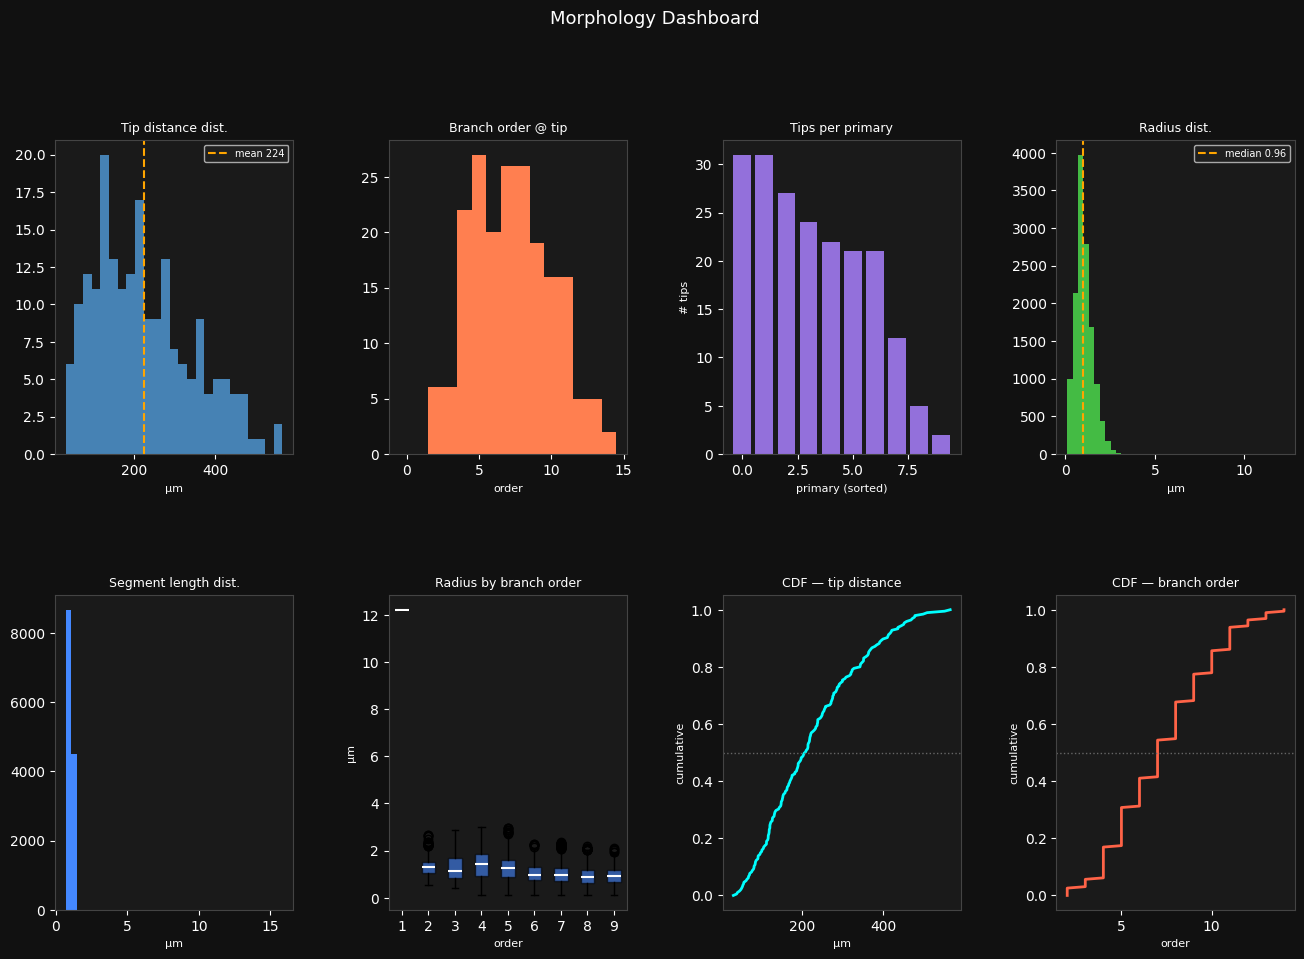

In [8]:
# ── Morphology Summary ───────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
import numpy as np

# ── Base calculations ────────────────────
radii_all   = np.array([swc_nodes[n]['r'] for n in swc_nodes])
bos_all     = np.array([branch_order.get(n, 0) for n in swc_nodes])
bos_tips    = np.array([branch_order.get(t, 0) for t in tips_ids])
seg_lens    = [dist_um(swc_nodes[n], swc_nodes[swc_nodes[n]['parent']])
               for n in swc_nodes
               if swc_nodes[n]['parent'] != -1 and swc_nodes[n]['parent'] in swc_nodes]

# Tips per primary
primary_of_tip = {}
for t in tips_ids:
    cur = t
    while cur in swc_nodes and swc_nodes[cur]['parent'] not in (-1, 1):
        cur = swc_nodes[cur]['parent']
    primary_of_tip[t] = cur
tips_per_primary = Counter(primary_of_tip.values())

# ── Text summary ───────────────────────────────────────────────
W = 52
print('╔' + '═'*W + '╗')
print(f'║{"  MORPHOLOGY SUMMARY":^{W}}║')
print('╠' + '═'*W + '╣')

def row(label, val, unit=''):
    s = f'  {label:<26}{val:<18}{unit}'
    print(f'║{s:<{W}}║')

def divider(title=''):
    if title:
        print(f'╠{"─"*W}╣')
        print(f'║  {title:<{W-2}}║')
        print(f'╠{"─"*W}╣')
    else:
        print(f'╠{"─"*W}╣')

divider('Soma')
row('Radius',         f'{soma_r_um:.2f}',      'µm')
row('Volume (sphere)',f'{4/3*np.pi*soma_r_um**3:.0f}', 'µm³')

divider('Structure')
row('Primary branches',  f'{len(primary_ids)}')
row('Branch points',     f'{len(branch_pts)}')
row('Tips',              f'{len(tips_ids)}')
row('Total nodes',       f'{len(swc_nodes):,}')

divider('Branch Order')
row('Max',               f'{int(bos_all.max())}')
row('Mean (all nodes)',  f'{bos_all.mean():.2f}')
row('Median (tips)',     f'{int(np.median(bos_tips))}')
row('Tips p75 order',    f'{int(np.percentile(bos_tips, 75))}')

divider('Path Length (soma surface corrected)')
tl = np.array(tip_lengths)
row('Total dendritic',   f'{morph["total_length_um"]:.0f}',  'µm')
row('Tip dist mean',     f'{tl.mean():.1f}',                 'µm')
row('Tip dist std',      f'{tl.std():.1f}',                  'µm')
row('Tip dist median',   f'{np.median(tl):.1f}',             'µm')
row('Tip dist max',      f'{tl.max():.1f}',                  'µm')
row('Tip dist min',      f'{tl.min():.1f}',                  'µm')

divider('Radius (EDT)')
row('Min',               f'{radii_all.min():.3f}',           'µm')
row('Median',            f'{np.median(radii_all):.3f}',      'µm')
row('Mean',              f'{radii_all.mean():.3f}',          'µm')
row('p99',               f'{np.percentile(radii_all,99):.3f}','µm')
row('Max',               f'{radii_all.max():.3f}',           'µm')

divider('Segment')
row('Mean seg length',   f'{np.mean(seg_lens):.3f}',         'µm')
row('Total segments',    f'{len(seg_lens):,}')

divider('Per-Primary (tips)')
pvals = sorted(tips_per_primary.values(), reverse=True)
row('Max tips/primary',  f'{pvals[0] if pvals else 0}')
row('Min tips/primary',  f'{pvals[-1] if pvals else 0}')
row('Mean tips/primary', f'{np.mean(pvals):.1f}' if pvals else '0')

print('╚' + '═'*W + '╝')

# ── Dashboard visualization ───────────────────────────────────────────
fig = plt.figure(figsize=(16, 10), facecolor='#111111')
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)

axes_list = [fig.add_subplot(gs[r,c]) for r in range(2) for c in range(4)]
for ax in axes_list:
    ax.set_facecolor('#1a1a1a'); ax.tick_params(colors='white')
    ax.spines[:].set_color('#444')

def ax_style(ax, title, xlabel='', ylabel=''):
    ax.set_title(title, color='white', fontsize=9)
    if xlabel: ax.set_xlabel(xlabel, color='white', fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, color='white', fontsize=8)

# 0: tip distance distribution
axes_list[0].hist(tl, bins=25, color='steelblue')
axes_list[0].axvline(tl.mean(), color='orange', ls='--', lw=1.5,
                     label=f'mean {tl.mean():.0f}')
axes_list[0].legend(facecolor='#222', labelcolor='white', fontsize=7)
ax_style(axes_list[0], 'Tip distance dist.', 'µm')

# 1: branch order at tip
axes_list[1].hist(bos_tips, bins=range(int(bos_tips.max())+2),
                  color='coral', align='left')
ax_style(axes_list[1], 'Branch order @ tip', 'order')

# 2: tips per primary
axes_list[2].bar(range(len(pvals)), pvals, color='mediumpurple')
ax_style(axes_list[2], 'Tips per primary', 'primary (sorted)', '# tips')

# 3: radius distribution
axes_list[3].hist(radii_all[radii_all > 0.05], bins=40, color='#44BB44')
axes_list[3].axvline(np.median(radii_all), color='orange', ls='--', lw=1.5,
                     label=f'median {np.median(radii_all):.2f}')
axes_list[3].legend(facecolor='#222', labelcolor='white', fontsize=7)
ax_style(axes_list[3], 'Radius dist.', 'µm')

# 4: segment length
axes_list[4].hist(seg_lens, bins=40, color='#4488FF')
ax_style(axes_list[4], 'Segment length dist.', 'µm')

# 5: radius by branch order (boxplot)
max_o = min(int(bos_all.max()), 8)
bdata = [radii_all[bos_all == o] for o in range(max_o+1)]
bdata = [d for d in bdata if len(d) > 0]
if bdata:
    bp = axes_list[5].boxplot(bdata, patch_artist=True,
                              medianprops=dict(color='white', lw=1.5))
    for patch in bp['boxes']:
        patch.set_facecolor('#4488FF'); patch.set_alpha(0.6)
ax_style(axes_list[5], 'Radius by branch order', 'order', 'µm')

# 6: cumulative tip distance
axes_list[6].plot(np.sort(tl), np.linspace(0,1,len(tl)),
                  color='cyan', lw=2)
axes_list[6].axhline(0.5, color='#666', ls=':', lw=1)
ax_style(axes_list[6], 'CDF — tip distance', 'µm', 'cumulative')

# 7: branch order CDF
bo_vals = np.sort(bos_tips)
axes_list[7].plot(bo_vals, np.linspace(0,1,len(bo_vals)),
                  color='tomato', lw=2)
axes_list[7].axhline(0.5, color='#666', ls=':', lw=1)
ax_style(axes_list[7], 'CDF — branch order', 'order', 'cumulative')

fig.suptitle('Morphology Dashboard', color='white', fontsize=13, y=1.01)
plt.show()

In [9]:
# ── 3D Tube Mesh: same primary → same color ────────────────────
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from collections import defaultdict

# ── Color palette per primary ────────────────────────────────────
primary_ids_list = sorted(children_map.get(1, []))
cmap   = plt.cm.tab20
PRIMARY_COLORS = {
    pid: f'rgb{tuple(int(c*255) for c in cmap(i / max(len(primary_ids_list), 1))[:3])}'
    for i, pid in enumerate(primary_ids_list)
}

def make_tube(node_ids, n_sides=6, sample=1):
    idx = list(range(0, len(node_ids), max(1, sample)))
    if idx[-1] != len(node_ids)-1: idx.append(len(node_ids)-1)
    nodes = [node_ids[i] for i in idx]
    if len(nodes) < 2: return None, None
    pts = np.array([[swc_nodes[n]['x'],swc_nodes[n]['y'],swc_nodes[n]['z']]
                    for n in nodes], dtype=np.float64)
    rs  = np.array([max(swc_nodes[n]['r'], 0.2) for n in nodes])
    rings = []; right = None
    for i,(p,r) in enumerate(zip(pts,rs)):
        t = pts[i+1]-pts[i] if i<len(pts)-1 else pts[i]-pts[i-1]
        tl = np.linalg.norm(t)
        t  = t/tl if tl>1e-8 else np.array([0.,0.,1.])
        if right is None:
            ref = np.array([0.,0.,1.]) if abs(t[2])<0.9 else np.array([1.,0.,0.])
            right = np.cross(t, ref)
        else:
            right = right - np.dot(right,t)*t
        rl = np.linalg.norm(right)
        right = np.cross(t, np.array([0.,0.,1.]) if abs(t[2])<0.9 else np.array([1.,0.,0.])) \
                if rl<1e-8 else right/rl
        up  = np.cross(t, right)
        ang = np.linspace(0, 2*np.pi, n_sides, endpoint=False)
        rings.append(p + r*(np.outer(np.cos(ang),right)+np.outer(np.sin(ang),up)))
    V = np.vstack(rings).astype(np.float32)
    F = []
    for i in range(len(rings)-1):
        for j in range(n_sides):
            k = (j+1)%n_sides
            v00,v01 = i*n_sides+j, i*n_sides+k
            v10,v11 = (i+1)*n_sides+j, (i+1)*n_sides+k
            F+=[[v00,v10,v01],[v01,v10,v11]]
    return V, np.array(F, dtype=np.int32)

def collect_segments():
    segs  = []
    stack = [(pid, [], pid) for pid in children_map.get(1,[])]
    while stack:
        node, path, panc = stack.pop()
        path = path+[node]
        kids = children_map.get(node,[])
        if not kids: segs.append((path, panc))
        elif len(kids)==1: stack.append((kids[0], path, panc))
        else:
            segs.append((path, panc))
            for kid in kids: stack.append((kid, [node], panc))
    return segs

segments = collect_segments()

# Accumulate mesh per primary
mesh_verts  = defaultdict(list)
mesh_faces  = defaultdict(list)
mesh_offset = defaultdict(int)

for path_ids, panc in segments:
    order  = branch_order.get(path_ids[0], 1)
    color  = PRIMARY_COLORS.get(panc, 'rgb(150,150,150)')
    sides  = 8 if order <= 1 else 6 if order <= 3 else 4
    sample = 1 if order <= 1 else 2
    V, F   = make_tube(path_ids, n_sides=sides, sample=sample)
    if V is None: continue
    mesh_faces[color].append(F + mesh_offset[color])
    mesh_verts[color].append(V)
    mesh_offset[color] += len(V)

# ── Figure ────────────────────────────────────────────────────
fig = go.Figure()

fig.add_trace(go.Mesh3d(
    x=sv[:,2], y=sv[:,1], z=sv[:,0],
    i=sf[:,0], j=sf[:,1], k=sf[:,2],
    color='#FF6B6B', opacity=0.85, flatshading=False,
    lighting=dict(ambient=0.5,diffuse=0.7,specular=0.3),
    lightposition=dict(x=3,y=3,z=5), name='Soma',
))

for i, (color, vlist) in enumerate(mesh_verts.items()):
    if not vlist: continue
    V_all = np.vstack(vlist)
    F_all = np.vstack(mesh_faces[color])
    pid   = primary_ids_list[i] if i < len(primary_ids_list) else '?'
    fig.add_trace(go.Mesh3d(
        x=V_all[:,0], y=V_all[:,1], z=V_all[:,2],
        i=F_all[:,0], j=F_all[:,1], k=F_all[:,2],
        color=color, opacity=1.0, flatshading=False,
        lighting=dict(ambient=0.4,diffuse=0.7,specular=0.4),
        lightposition=dict(x=3,y=3,z=5),
        name=f'Primary {pid}',
    ))

fig.update_layout(
    title=dict(text='Neuron Tube Mesh — color: primary branch lineage', font=dict(color='white')),
    scene=dict(
        xaxis_title='X (µm)', yaxis_title='Y (µm)', zaxis_title='Z (µm)',
        bgcolor='#080808',
        xaxis=dict(backgroundcolor='#080808',gridcolor='#1a1a1a',color='white'),
        yaxis=dict(backgroundcolor='#080808',gridcolor='#1a1a1a',color='white'),
        zaxis=dict(backgroundcolor='#080808',gridcolor='#1a1a1a',color='white'),
        aspectmode='data',
    ),
    paper_bgcolor='#111111', font_color='white',
    margin=dict(l=0,r=0,t=50,b=0),
    legend=dict(x=0.01,y=0.99,bgcolor='rgba(20,20,20,0.85)'),
)
fig.show()
print(f'Primary branches: {len(primary_ids_list)}')

Primary branches: 10


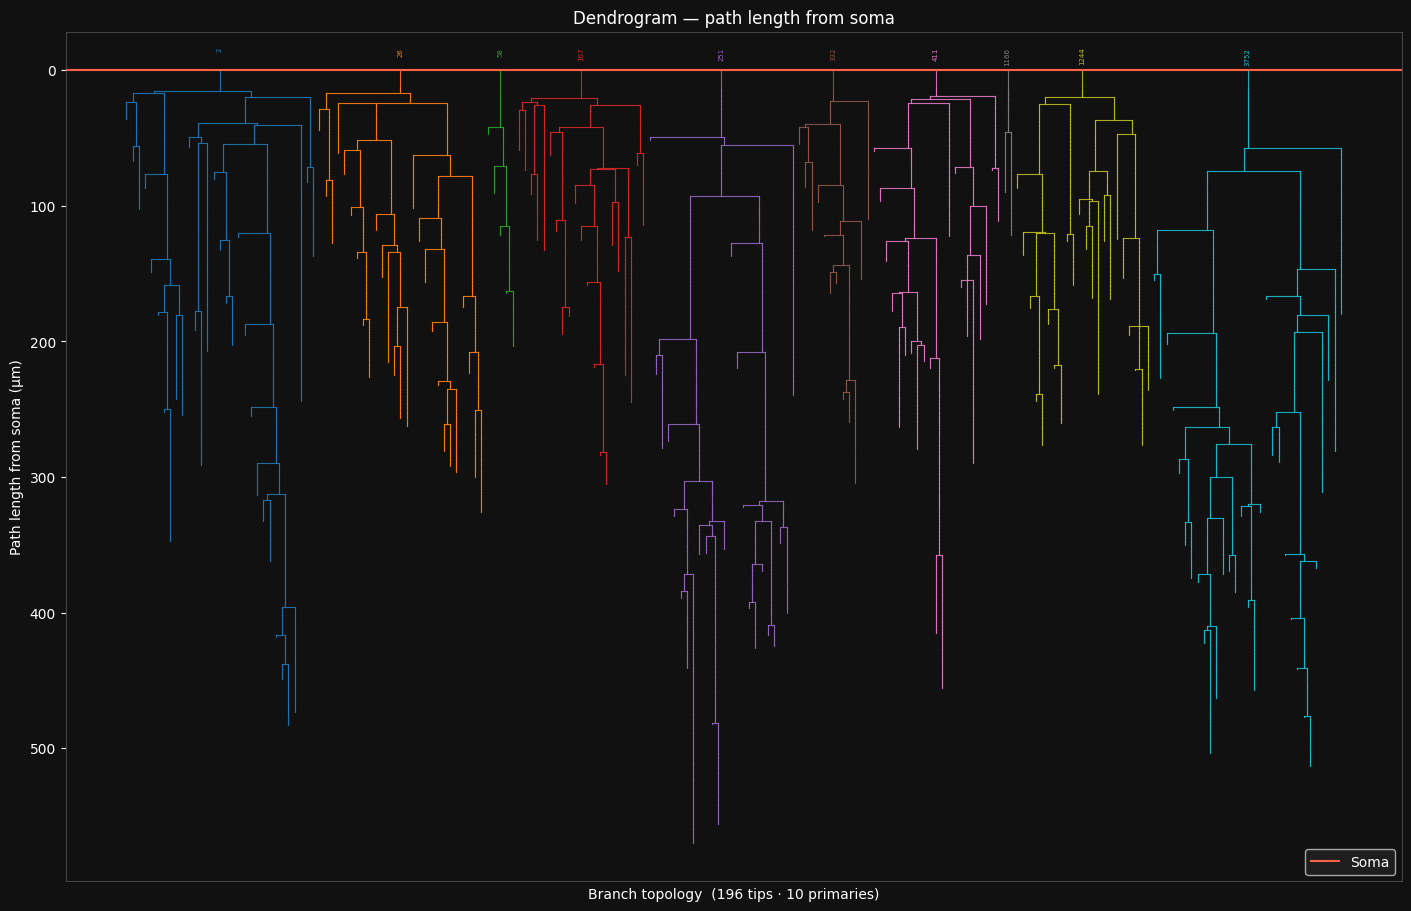

Tips: 196  |  Primaries: 10  |  Max depth: 569.9 µm


In [10]:
# ── Dendrogram (vertical topology) ──────────────────────────
import matplotlib.pyplot as plt, sys
sys.setrecursionlimit(200000)

cmap_p  = plt.cm.tab20
p_color = {pid: cmap_p(i / max(len(primary_ids), 1))
           for i, pid in enumerate(primary_ids)}

# Phase 1: compute x-center per node via DFS
# leaf = unique x slot, internal node = midpoint of children range
leaf_x = [0]
x_mid  = {}

def assign_x(nid):
    kids = children_map.get(nid, [])
    if not kids:
        x_mid[nid] = float(leaf_x[0])
        leaf_x[0] += 1
        return leaf_x[0] - 1, leaf_x[0] - 1
    spans = [assign_x(k) for k in sorted(kids)]
    x_mid[nid] = (spans[0][0] + spans[-1][1]) / 2.0
    return spans[0][0], spans[-1][1]

for pid in sorted(primary_ids):
    assign_x(pid)

n_tips = leaf_x[0]

# Phase 2: draw vertical lines
# Y axis = path length from soma; top=soma(0), bottom=tips
fig, ax = plt.subplots(figsize=(max(14, n_tips * 0.06 + 2), 9),
                       constrained_layout=True)
fig.patch.set_facecolor('#111111')
ax.set_facecolor('#111111')

def draw_v(nid, y_parent, color):
    kids  = children_map.get(nid, [])
    y_cur = path_len.get(nid, 0.0)
    xc    = x_mid.get(nid, 0.0)
    # vertical line to this node (parent BP → current depth)
    ax.plot([xc, xc], [y_parent, y_cur], '-', color=color, lw=0.8, alpha=0.9)
    if not kids:
        return
    if len(kids) > 1:  # branch point → horizontal connector
        cxs = [x_mid[k] for k in sorted(kids)]
        ax.plot([min(cxs), max(cxs)], [y_cur, y_cur],
                '-', color=color, lw=0.8, alpha=0.9)
    for k in sorted(kids):
        draw_v(k, y_cur, color)

for pid in sorted(primary_ids):
    draw_v(pid, 0.0, p_color.get(pid, 'white'))

# Soma baseline
ax.axhline(0, color='tomato', lw=1.5, label='Soma', zorder=5)

# Primary labels (top)
y_label = -max(path_len.values()) * 0.03
for pid in sorted(primary_ids):
    ax.text(x_mid[pid], y_label, str(pid),
            color=p_color[pid], fontsize=5,
            ha='center', va='top', rotation=90)

ax.invert_yaxis()   # soma top, tips bottom
ax.set_xticks([])
ax.set_ylabel('Path length from soma (µm)', color='white')
ax.set_xlabel(
    f'Branch topology  ({n_tips} tips · {len(primary_ids)} primaries)',
    color='white')
ax.set_title('Dendrogram — path length from soma', color='white')
ax.tick_params(colors='white')
ax.spines[:].set_color('#444')
ax.legend(facecolor='#222', labelcolor='white', loc='lower right')
plt.show()
print(f'Tips: {n_tips}  |  Primaries: {len(primary_ids)}  |  '
      f'Max depth: {max(path_len.values()):.1f} µm')


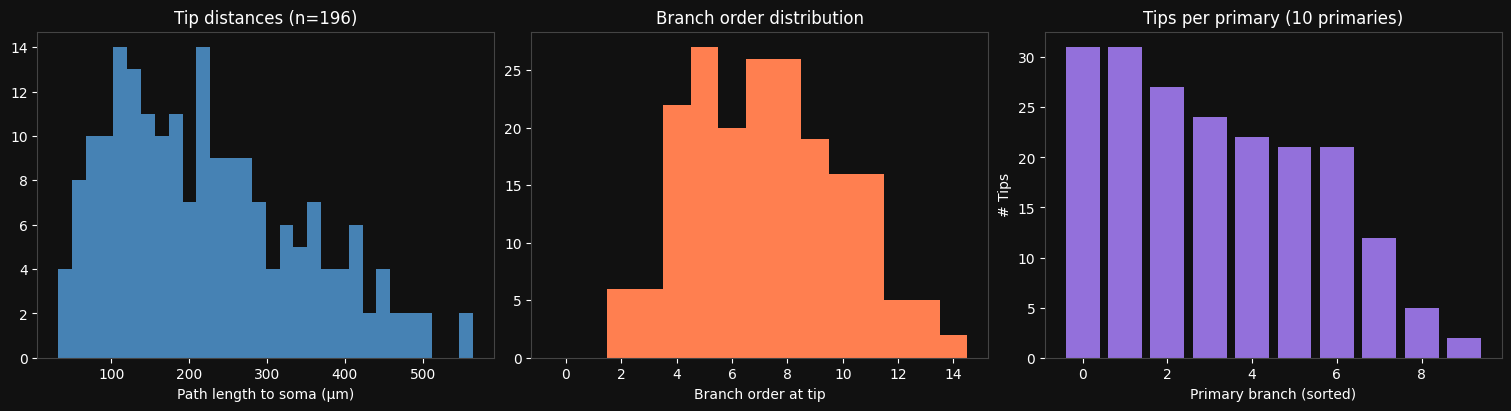

In [11]:
# ── Branch distribution ────────────────────────────────────────────────
import matplotlib.pyplot as plt
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
fig.patch.set_facecolor('#111111')
for ax in axes:
    ax.set_facecolor('#111111'); ax.tick_params(colors='white'); ax.spines[:].set_color('#444')

axes[0].hist(tip_lengths, bins=30, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Path length to soma (µm)', color='white')
axes[0].set_title(f'Tip distances (n={len(tips_ids)})', color='white')

bos = [branch_order.get(t, 0) for t in tips_ids]
axes[1].hist(bos, bins=range(max(bos)+2) if bos else 1,
             color='coral', edgecolor='none', align='left')
axes[1].set_xlabel('Branch order at tip', color='white')
axes[1].set_title('Branch order distribution', color='white')

primary_of_tip = {}
for t in tips_ids:
    cur = t
    while cur in swc_nodes and swc_nodes[cur]['parent'] not in (-1, 1):
        cur = swc_nodes[cur]['parent']
    primary_of_tip[t] = cur
tips_per_p = Counter(primary_of_tip.values())
vals = sorted(tips_per_p.values(), reverse=True)
axes[2].bar(range(len(vals)), vals, color='mediumpurple', edgecolor='none')
axes[2].set_xlabel('Primary branch (sorted)', color='white')
axes[2].set_ylabel('# Tips', color='white')
axes[2].set_title(f'Tips per primary ({len(primary_ids)} primaries)', color='white')

plt.show()

In [ ]:
# ── Radius colormap visualization ────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import plotly.graph_objects as go

nids   = list(swc_nodes.keys())
radii  = np.array([swc_nodes[n]['r'] for n in nids])

r_min, r_max = radii.min(), np.percentile(radii, 99)
print(f'Radius  min={radii.min():.3f}  median={np.median(radii):.3f}  '
      f'p99={np.percentile(radii,99):.3f}  max={radii.max():.3f} µm')

primary_ids = children_map.get(1, [])
print(f'\nFirst-node radius per primary:')
for pid in sorted(primary_ids):
    n = swc_nodes[pid]
    print(f'  pid {pid}: r={n["r"]:.3f} µm')

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
fig.patch.set_facecolor('#111111')
for ax in axes:
    ax.set_facecolor('#111111'); ax.tick_params(colors='white'); ax.spines[:].set_color('#444')

axes[0].hist(radii, bins=60, color='steelblue', edgecolor='none')
axes[0].axvline(np.median(radii), color='orange', ls='--', label=f'median {np.median(radii):.2f} µm')
axes[0].axvline(0.5, color='red', ls=':', label='0.5 µm')
axes[0].set_xlabel('Radius (µm)', color='white')
axes[0].set_title('All-node radius distribution', color='white')
axes[0].legend(facecolor='#222', labelcolor='white', fontsize=8)

orders = [branch_order.get(n, 0) for n in nids]
max_o  = min(max(orders), 8)
data   = [radii[np.array(orders) == o] for o in range(max_o+1)]
bp = axes[1].boxplot(data, patch_artist=True,
                     medianprops=dict(color='white', lw=2))
for patch, o in zip(bp['boxes'], range(max_o+1)):
    patch.set_facecolor(order_color(o))
    patch.set_alpha(0.7)
axes[1].set_xlabel('Branch order', color='white')
axes[1].set_ylabel('Radius (µm)', color='white')
axes[1].set_title('Radius by branch order', color='white')
axes[1].set_xticklabels(range(max_o+1))
plt.show()

# ── MIP overlay: radius color (step0 voxel_iso 사용) ────────────
import tifffile
_meta_mip = np.load(PREP_NPZ.replace('prep_riem.npz', 'preprocess_meta.npz'))
_viso_mip = float(_meta_mip['voxel_iso'])   # step0 해상도

stack     = tifffile.imread(STACK_TIF).astype(np.float32)
mip_xy    = stack.max(axis=0) / stack.max()
del stack

cmap_r = cm.get_cmap('RdYlGn')

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
fig.patch.set_facecolor('#111111')
ax.imshow(mip_xy, cmap='gray', origin='upper', vmin=0, vmax=0.8, aspect='equal')
ax.axis('off')

for nid, n in swc_nodes.items():
    par_id = n['parent']
    if par_id == -1 or par_id not in swc_nodes: continue
    p = swc_nodes[par_id]
    r_norm = np.clip((n['r'] - r_min) / (r_max - r_min + 1e-8), 0, 1)
    color  = cmap_r(r_norm)
    ax.plot([n['x']/_viso_mip, p['x']/_viso_mip],
            [n['y']/_viso_mip, p['y']/_viso_mip],
            '-', color=color, lw=0.8, alpha=0.8)

sm = plt.cm.ScalarMappable(cmap=cmap_r, norm=plt.Normalize(vmin=r_min, vmax=r_max))
cb = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('Radius (µm)', color='white')
cb.ax.tick_params(colors='white')
ax.set_title(f'Radius colormap — XY MIP  (red=thin, green=thick)  voxel={_viso_mip:.4f}µm', color='white')
fig.patch.set_facecolor('#111111')
plt.show()

In [ ]:
# ── Non-terminal thin removal + Min segment filter ────────────────────
import copy
from collections import defaultdict, deque
import numpy as np

# ── Step 1: Non-terminal thin removal ────────────────────────
# 전략: tip이 아닌 곳에서 극도로 얇은 노드 → false connection → 제거
# tip 근처(SAFE_HOPS 이내)는 자연스러운 terminal thinning → 보존
THIN_CUT   = 0.40   # 이 값 미만이면 "극단적으로 얇음"
SAFE_HOPS  = 15     # tip으로부터 이 hop 수 이내 → terminal thin → 보존
SOMA_SAFE  = 20.0   # soma 근처(µm) → 보존

soma_pos = np.array([swc_nodes[1]['x'], swc_nodes[1]['y'], swc_nodes[1]['z']])

def _build_cm(nds):
    cm = defaultdict(list)
    for nid,n in nds.items():
        if n['parent']!=-1: cm[n['parent']].append(nid)
    return cm

_cm = _build_cm(swc_nodes)

# BFS from all tips to compute distance-to-nearest-tip
tips_set = set(nid for nid in swc_nodes if nid!=1 and not _cm.get(nid))
dist_to_tip = {}
bfs_q = deque()
for tip in tips_set:
    dist_to_tip[tip] = 0
    bfs_q.append((tip, 0))
while bfs_q:
    nid, d = bfs_q.popleft()
    par = swc_nodes[nid]['parent']
    if par != -1 and par in swc_nodes:
        if par not in dist_to_tip or dist_to_tip[par] > d+1:
            dist_to_tip[par] = d+1
            bfs_q.append((par, d+1))

def _get_segs(nds, cm2):
    segs=[]
    for nid,n in nds.items():
        if n['parent']==-1: continue
        if len(cm2.get(n['parent'],[]))>=2 or nds[n['parent']]['parent']==-1:
            path=[nid]; cur=nid
            while len(cm2.get(cur,[]))==1: cur=cm2[cur][0]; path.append(cur)
            segs.append(path)
    return segs

to_remove_bt = set()
n_cuts = 0
for seg in _get_segs(swc_nodes, _cm):
    cut_at = None
    for i, nid in enumerate(seg):
        n = swc_nodes[nid]
        if n['r'] >= THIN_CUT: continue
        if dist_to_tip.get(nid, 9999) <= SAFE_HOPS: continue  # terminal 근처 OK
        d_soma = np.linalg.norm([n['x']-soma_pos[0],n['y']-soma_pos[1],n['z']-soma_pos[2]])
        if d_soma < SOMA_SAFE: continue
        cut_at = i; break
    if cut_at is None: continue
    q=deque(seg[cut_at:]); seen=set()
    while q:
        nd=q.popleft()
        if nd in seen: continue
        seen.add(nd); to_remove_bt.add(nd)
        for c in _cm.get(nd,[]):
            if c not in seen: q.append(c)
    n_cuts += 1

swc_bt = {nid:n for nid,n in swc_nodes.items() if nid not in to_remove_bt}
for nid,n in list(swc_bt.items()):
    if n['parent'] in to_remove_bt: swc_bt[nid]={**n,'parent':1}
print(f'Non-terminal thin filter: {n_cuts}개 컷, {len(to_remove_bt):,} nodes 제거')
print(f'  {len(swc_nodes):,} → {len(swc_bt):,} nodes  (THIN_CUT={THIN_CUT}, SAFE_HOPS={SAFE_HOPS})')

# ── Step 2: Min segment length filter ────────────────────────
soma_threshold = soma_r_um * 1.5
def dist_um(a, b): return np.sqrt((a['x']-b['x'])**2+(a['y']-b['y'])**2+(a['z']-b['z'])**2)

def seg_to_parent_tp(nid, nodes, ch_map):
    chain=[]; length=0.0; cur=nodes[nid]['parent']
    if cur==-1: return None,chain,0.0
    length+=dist_um(nodes[nid],nodes[cur])
    while cur!=1 and len(ch_map.get(cur,[]))<2:
        chain.append(cur); prev=cur; cur=nodes[cur]['parent']
        if cur==-1: return None,chain,length
        length+=dist_um(nodes[prev],nodes[cur])
    return cur,chain,length

ch_map = defaultdict(list)
for nid,n in swc_bt.items():
    if n['parent']!=-1: ch_map[n['parent']].append(nid)
bp_list = [nid for nid,n in swc_bt.items() if nid!=1 and len(ch_map.get(nid,[]))>=2]

to_collapse={}
for bp in bp_list:
    n=swc_bt[bp]; bp_pos=np.array([n['x'],n['y'],n['z']])
    if np.linalg.norm(bp_pos-soma_pos)<soma_threshold: continue
    tp,chain,seg_len=seg_to_parent_tp(bp,swc_bt,ch_map)
    if tp is None: continue
    if seg_len<MIN_SEGMENT_LEN_UM: to_collapse[bp]=(tp,chain)

forwarding={}; nodes_filt=copy.deepcopy(swc_bt); del_ids=set()
for bp,(tp,chain) in to_collapse.items():
    if tp==1: continue
    forwarding[bp]=tp
    for c in chain: forwarding[c]=tp
    if bp not in nodes_filt: continue
    for ch in ch_map.get(bp,[]):
        if ch in nodes_filt: nodes_filt[ch]['parent']=tp
    del_ids.add(bp); del_ids.update(chain)
for nid in del_ids: nodes_filt.pop(nid,None)

def resolve_tp(pid):
    seen=set()
    while pid in forwarding:
        if pid in seen: break
        seen.add(pid); pid=forwarding[pid]
    return pid

id_map={-1:-1}
for new_id,old_id in enumerate(sorted(nodes_filt.keys()),start=1): id_map[old_id]=new_id
nodes_clean={}
for old_id,node in nodes_filt.items():
    new_id=id_map[old_id]; resolved=resolve_tp(node['parent'])
    new_par=id_map.get(resolved,1)
    nodes_clean[new_id]={**node,'parent':new_par}

ch_clean=defaultdict(list)
for nid,n in nodes_clean.items():
    if n['parent']!=-1: ch_clean[n['parent']].append(nid)
bp_clean=[nid for nid in nodes_clean if nid!=1 and len(ch_clean.get(nid,[]))>=2]

bo_clean={1:0}; q=[1]
while q:
    cur=q.pop(0); kids=ch_clean.get(cur,[])
    for ch in kids:
        bo_clean[ch]=bo_clean[cur]+(1 if len(kids)>=2 else 0); q.append(ch)
tip_orders=[bo_clean[nid] for nid in nodes_clean if not ch_clean.get(nid)]

print(f'Min-seg filter: {len(to_collapse):,} BP 제거')
print(f'  {len(swc_bt):,} → {len(nodes_clean):,} nodes (최종)')
print(f'Max branch order: {max(bo_clean.values())}  Tip median: {int(np.median(tip_orders))}')

OUT_CLEAN = SWC_FILE.replace('.swc', '_seg.swc')
lines=[f'# NonTerminalThin+MinSeg: {len(nodes_clean):,} nodes']
for nid in sorted(nodes_clean.keys()):
    n=nodes_clean[nid]
    lines.append(f"{nid} {n['type']} {n['x']:.4f} {n['y']:.4f} {n['z']:.4f} {n['r']:.4f} {n['parent']}")
with open(OUT_CLEAN,'w') as f: f.write('\n'.join(lines)+'\n')
print(f'Saved: {OUT_CLEAN}')

In [ ]:
# (이 셀은 cc9049fb에 통합됨 — 실행 불필요)

In [14]:
# ── Morphology: after seg filter ────────────────────────────
from scipy.spatial import cKDTree as _cKDTree

# ── Soma surface correction ───────────────────────────────────
_soma_pts  = np.column_stack([sv[:,2], sv[:,1], sv[:,0]])
_soma_tree = _cKDTree(_soma_pts)
_soma_c    = nodes_clean[1]

_prim_corr = {}
for _nid in ch_clean.get(1, []):
    _n = nodes_clean[_nid]
    _, _idx = _soma_tree.query([_n['x'], _n['y'], _n['z']])
    _sx, _sy, _sz = _soma_pts[_idx]
    _prim_corr[_nid] = np.sqrt((_sx-_soma_c['x'])**2+(_sy-_soma_c['y'])**2+(_sz-_soma_c['z'])**2)

def _get_prim(nid):
    cur = nid
    while nodes_clean[cur]['parent'] not in (-1, 1):
        cur = nodes_clean[cur]['parent']
    return cur

def _path_len(tip_id):
    length, cur = 0.0, tip_id
    while nodes_clean[cur]['parent'] != -1:
        par = nodes_clean[cur]['parent']
        if par not in nodes_clean: break
        length += dist_um(nodes_clean[cur], nodes_clean[par])
        cur = par
    return max(length - _prim_corr.get(_get_prim(tip_id), 0.0), 0.0)

_tips_c   = [n for n in nodes_clean if not ch_clean.get(n)]
_bps_c    = [n for n in nodes_clean if len(ch_clean.get(n,[])) >= 2]
_prims_c  = ch_clean.get(1, [])
_seg_raw  = sum(dist_um(nodes_clean[n], nodes_clean[nodes_clean[n]['parent']])
                for n in nodes_clean if nodes_clean[n]['parent'] != -1
                and nodes_clean[n]['parent'] in nodes_clean)
_corr_tot = sum(_prim_corr.values())
_tip_lens = [_path_len(t) for t in _tips_c]
_bos_tips = [bo_clean.get(t, 0) for t in _tips_c]
_radii_c  = [nodes_clean[n]['r'] for n in nodes_clean]

W = 52
def _row(label, val, unit=''):
    s = f'  {label:<26}{val:<18}{unit}'
    print(f'║{s:<{W}}║')
def _div(title=''):
    if title:
        print(f'╠{"─"*W}╣'); print(f'║  {title:<{W-2}}║'); print(f'╠{"─"*W}╣')
    else:
        print(f'╠{"─"*W}╣')

print('╔' + '═'*W + '╗')
print(f'║{"  MORPHOLOGY — SEG FILTERED":^{W}}║')
print('╠' + '═'*W + '╣')
_div('Soma')
_row('Radius',         f'{soma_r_um:.2f}',      'µm')
_div('Structure')
_row('Primary branches',  f'{len(_prims_c)}')
_row('Branch points',     f'{len(_bps_c):,}')
_row('Tips',              f'{len(_tips_c):,}')
_row('Total nodes',       f'{len(nodes_clean):,}')
_div('Branch Order')
_row('Max',               f'{max(bo_clean.values())}')
_row('Mean (all nodes)',  f'{np.mean(list(bo_clean.values())):.2f}')
_row('Median (tips)',     f'{int(np.median(_bos_tips))}')
_row('Tips p75 order',    f'{int(np.percentile(_bos_tips, 75))}')
_div('Path Length (soma surface corrected)')
_tl = np.array(_tip_lens)
_row('Total dendritic',   f'{_seg_raw-_corr_tot:.0f}',  'µm')
_row('Tip dist mean',     f'{_tl.mean():.1f}',           'µm')
_row('Tip dist std',      f'{_tl.std():.1f}',            'µm')
_row('Tip dist median',   f'{np.median(_tl):.1f}',       'µm')
_row('Tip dist max',      f'{_tl.max():.1f}',            'µm')
_row('Tip dist min',      f'{_tl.min():.1f}',            'µm')
_div('Radius (EDT)')
_ra = np.array(_radii_c)
_row('Min',   f'{_ra.min():.3f}',             'µm')
_row('Median',f'{np.median(_ra):.3f}',        'µm')
_row('Mean',  f'{_ra.mean():.3f}',            'µm')
_row('p99',   f'{np.percentile(_ra,99):.3f}', 'µm')
_row('Max',   f'{_ra.max():.3f}',             'µm')
_div('Per-Primary (tips)')
from collections import Counter as _Counter
_pa_of_tip = {}
for _t in _tips_c:
    _cur = _t
    while nodes_clean[_cur]['parent'] not in (-1, 1):
        _cur = nodes_clean[_cur]['parent']
    _pa_of_tip[_t] = _cur
_tpp = sorted(_Counter(_pa_of_tip.values()).values(), reverse=True)
_row('Max tips/primary',  f'{_tpp[0] if _tpp else 0}')
_row('Min tips/primary',  f'{_tpp[-1] if _tpp else 0}')
_row('Mean tips/primary', f'{np.mean(_tpp):.1f}' if _tpp else '0')
print('╚' + '═'*W + '╝')


╔════════════════════════════════════════════════════╗
║              MORPHOLOGY — SEG FILTERED             ║
╠════════════════════════════════════════════════════╣
╠────────────────────────────────────────────────────╣
║  Soma                                              ║
╠────────────────────────────────────────────────────╣
║  Radius                    12.22             µm    ║
╠────────────────────────────────────────────────────╣
║  Structure                                         ║
╠────────────────────────────────────────────────────╣
║  Primary branches          10                      ║
║  Branch points             139                     ║
║  Tips                      196                     ║
║  Total nodes               12,881                  ║
╠────────────────────────────────────────────────────╣
║  Branch Order                                      ║
╠────────────────────────────────────────────────────╣
║  Max                       12                      ║
║  Mean (a

In [ ]:
# ── Primary branch merge (소마 과다 감지로 분리된 같은 가지 합치기) ────────
# 문제: soma 반경(9.6µm)이 dendrite 시작 부분을 포함 → 하나의 dendrite가
#       여러 primary로 분리됨. 같은 방향(angle<20°)인 primary들을 병합.
from collections import defaultdict as _dd2, deque as _dq2
import copy as _copy2

MERGE_ANGLE_THR = 20.0   # 이 각도 이내면 같은 dendrite 후보
SOMA_EXIT_FRAC  = 0.75   # soma_r × 이 비율 = 소마 탈출 거리

_soma_r = float(np.load(PREP_NPZ)['soma_r_um'])
_soma_c = np.array([nodes_clean[1]['x'], nodes_clean[1]['y'], nodes_clean[1]['z']])

def _dist_soma(nid): 
    n=nodes_clean[nid]
    return np.linalg.norm([n['x']-_soma_c[0],n['y']-_soma_c[1],n['z']-_soma_c[2]])

# Primary list in nodes_clean
_cm2 = defaultdict(list)
for nid,n in nodes_clean.items():
    if n['parent']!=-1: _cm2[n['parent']].append(nid)
_pids = sorted(_cm2.get(1,[]))

# Branch direction: average of first DIRECTION_STEPS nodes' movement vectors
DIRECTION_STEPS = 30
def _branch_dir(pid):
    path=[pid]; cur=pid
    for _ in range(DIRECTION_STEPS):
        kids=_cm2.get(cur,[])
        if not kids: break
        cur=max(kids, key=lambda k: sum(1 for _ in _dq2([k])))
        path.append(cur)
    if len(path)<2: return np.array([0.,0.,1.])
    s=np.array([nodes_clean[path[0]]['x'],nodes_clean[path[0]]['y'],nodes_clean[path[0]]['z']])
    e=np.array([nodes_clean[path[-1]]['x'],nodes_clean[path[-1]]['y'],nodes_clean[path[-1]]['z']])
    d=e-s; return d/(np.linalg.norm(d)+1e-8)

def _subtree_size(pid):
    st=set(); q=_dq2([pid])
    while q:
        n=q.popleft(); st.add(n); q.extend(_cm2.get(n,[]))
    return len(st)

# Build direction vectors and find clusters
_dirs = {pid: _branch_dir(pid) for pid in _pids}
_sizes = {pid: _subtree_size(pid) for pid in _pids}

# Greedy clustering by angle
_visited = set(); _clusters = []
for pid in sorted(_pids, key=lambda p: -_sizes[p]):  # largest first
    if pid in _visited: continue
    cluster = [pid]; _visited.add(pid)
    for other in _pids:
        if other in _visited: continue
        cos = float(np.dot(_dirs[pid], _dirs[other]))
        cos = np.clip(cos, -1, 1)
        if np.degrees(np.arccos(cos)) < MERGE_ANGLE_THR:
            cluster.append(other); _visited.add(other)
    _clusters.append(cluster)

print(f"Primary branches: {len(_pids)} → {len(_clusters)} clusters (merge threshold={MERGE_ANGLE_THR}°)")
for ci,cl in enumerate(_clusters):
    total_n = sum(_sizes[p] for p in cl)
    print(f"  Cluster {ci+1}: {[str(p) for p in sorted(cl, key=lambda p:-_sizes[p])]}  ({total_n} nodes total)")

# Perform merge: for each cluster, attach smaller branches' outside-soma portions to main
nodes_merged = _copy2.deepcopy(nodes_clean)
_cm_m = defaultdict(list)
for nid,n in nodes_merged.items():
    if n['parent']!=-1: _cm_m[n['parent']].append(nid)

n_merged = 0
for cluster in _clusters:
    if len(cluster) <= 1: continue
    # Main = largest
    main = max(cluster, key=lambda p: _sizes[p])
    secondaries = [p for p in cluster if p != main]
    
    # Build main branch path (outside soma portion)
    main_outside = []
    q=_dq2([main])
    while q:
        nid=q.popleft()
        if _dist_soma(nid) > _soma_r * SOMA_EXIT_FRAC:
            main_outside.append(nid)
        q.extend(_cm_m.get(nid,[]))
    
    if not main_outside: continue
    main_pts = np.array([[nodes_merged[n]['x'],nodes_merged[n]['y'],nodes_merged[n]['z']]
                         for n in main_outside])
    
    for sec in secondaries:
        # Find first outside-soma node in secondary
        sec_path = [sec]; cur = sec
        for _ in range(200):
            kids = _cm_m.get(cur, [])
            if not kids: break
            cur = kids[0]; sec_path.append(cur)
        
        exit_idx = next((i for i,n in enumerate(sec_path) 
                        if _dist_soma(n) > _soma_r * SOMA_EXIT_FRAC), None)
        if exit_idx is None: continue
        exit_node = sec_path[exit_idx]
        
        # Find closest main branch node to exit_node
        exit_pos = np.array([nodes_merged[exit_node]['x'],
                             nodes_merged[exit_node]['y'],
                             nodes_merged[exit_node]['z']])
        dists = np.linalg.norm(main_pts - exit_pos, axis=1)
        attach = main_outside[int(dists.argmin())]
        
        # Re-parent exit_node to attach
        nodes_merged[exit_node] = {**nodes_merged[exit_node], 'parent': attach}
        _cm_m[attach].append(exit_node)
        if 1 in _cm_m: _cm_m[1] = [n for n in _cm_m[1] if n != sec]
        
        # Remove secondary's soma-internal nodes (before exit_node)
        to_del = set(sec_path[:exit_idx])
        for d in to_del:
            nodes_merged.pop(d, None)
            _cm_m.pop(d, None)
        
        n_merged += 1
        print(f"  Merged pid={sec} → attach to main={main} at node={attach}")

# Rebuild clean nodes_clean with merged structure
nodes_clean = nodes_merged
# Rebuild ch_clean and bo_clean
ch_clean = defaultdict(list)
for nid,n in nodes_clean.items():
    if n['parent']!=-1: ch_clean[n['parent']].append(nid)
bp_clean = [nid for nid in nodes_clean if nid!=1 and len(ch_clean.get(nid,[]))>=2]
bo_clean = {1:0}; q=[1]
while q:
    cur=q.pop(0); kids=ch_clean.get(cur,[])
    for ch in kids:
        bo_clean[ch]=bo_clean[cur]+(1 if len(kids)>=2 else 0); q.append(ch)

new_pids = sorted(ch_clean.get(1,[]))
print(f"\nAfter merge: {len(nodes_clean):,} nodes, {len(new_pids)} primary branches")
print(f"Primary branch sizes: {sorted([(p,sum(1 for _ in _dq2([p]))) for p in new_pids], key=lambda x:-x[1])[:5]}")

In [ ]:
# ── Seg-filtered SWC visualization ──────────────────────────────────
import matplotlib.pyplot as plt
import tifffile

try:
    mip_xy
except NameError:
    _stack   = tifffile.imread(STACK_TIF).astype(np.float32)
    mip_xy   = _stack.max(axis=0) / _stack.max()
    voxel_iso = float(np.load(PREP_NPZ)['voxel_iso'])
    del _stack

soma_n = nodes_clean[1]

fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)
fig.patch.set_facecolor('#111111')
for ax in axes:
    ax.imshow(mip_xy, cmap='gray', origin='upper', vmin=0, vmax=0.8, aspect='equal')
    ax.axis('off')

for nid, n in swc_nodes.items():
    par = n['parent']
    if par == -1 or par not in swc_nodes: continue
    p = swc_nodes[par]
    o = branch_order.get(nid, 0)
    axes[0].plot([n['x']/voxel_iso, p['x']/voxel_iso],
                 [n['y']/voxel_iso, p['y']/voxel_iso],
                 '-', color=order_color(o), lw=0.6, alpha=0.7)
axes[0].scatter([swc_nodes[1]['x']/voxel_iso], [swc_nodes[1]['y']/voxel_iso],
                c='white', s=80, marker='*', zorder=5)
axes[0].set_title(f'Original  |  order max={max(branch_order.values())}  '
                  f'BP={sum(1 for n in swc_nodes if len(ch_map.get(n,[]))>=2)}',
                  color='white', fontsize=10)

for nid, n in nodes_clean.items():
    par = n['parent']
    if par == -1 or par not in nodes_clean: continue
    p = nodes_clean[par]
    o = bo_clean.get(nid, 0)
    axes[1].plot([n['x']/voxel_iso, p['x']/voxel_iso],
                 [n['y']/voxel_iso, p['y']/voxel_iso],
                 '-', color=order_color(o), lw=0.6, alpha=0.7)
axes[1].scatter([soma_n['x']/voxel_iso], [soma_n['y']/voxel_iso],
                c='white', s=80, marker='*', zorder=5)
axes[1].set_title(f'After seg filter  |  order max={max(bo_clean.values())}  '
                  f'BP={len(bp_clean)}',
                  color='white', fontsize=10)

fig.suptitle(f'Before / after min segment filter  (MIN_SEGMENT_LEN_UM={MIN_SEGMENT_LEN_UM} µm)',
             color='white', fontsize=12)
plt.show()


In [ ]:
# ── Seg-filtered + Merged 3D Tube Mesh ──────────────────────
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

ch_clean_local = defaultdict(list)
for nid, n in nodes_clean.items():
    if n['parent'] != -1:
        ch_clean_local[n['parent']].append(nid)

primary_ids_clean = sorted(ch_clean_local.get(1, []))
cmap_c   = plt.cm.tab20
PCOLORS  = {
    pid: f'rgb{tuple(int(c*255) for c in cmap_c(i/max(len(primary_ids_clean),1))[:3])}'
    for i, pid in enumerate(primary_ids_clean)
}

# Soma parameters for clipping
_soma_r_viz  = float(np.load(PREP_NPZ)['soma_r_um'])
_soma_c_viz  = np.array([nodes_clean[1]['x'],nodes_clean[1]['y'],nodes_clean[1]['z']])
def _in_soma(nid):
    n=nodes_clean[nid]
    return np.linalg.norm([n['x']-_soma_c_viz[0],n['y']-_soma_c_viz[1],n['z']-_soma_c_viz[2]]) < _soma_r_viz * 0.92

def make_tube_clean(node_ids, n_sides=6, sample=1):
    # Clip: start from first node OUTSIDE soma
    start = next((i for i,nid in enumerate(node_ids) if not _in_soma(nid)), None)
    if start is None: return None, None
    node_ids = node_ids[start:]
    
    idx = list(range(0, len(node_ids), max(1, sample)))
    if idx[-1] != len(node_ids) - 1: idx.append(len(node_ids) - 1)
    nodes_sel = [node_ids[i] for i in idx]
    if len(nodes_sel) < 2: return None, None
    pts = np.array([[nodes_clean[n]['x'], nodes_clean[n]['y'], nodes_clean[n]['z']]
                    for n in nodes_sel], dtype=np.float64)
    rs  = np.array([max(nodes_clean[n]['r'], 0.15) for n in nodes_sel])
    rings = []; right = None
    for i, (p, r) in enumerate(zip(pts, rs)):
        t = pts[i+1] - pts[i] if i < len(pts)-1 else pts[i] - pts[i-1]
        tl = np.linalg.norm(t)
        t  = t / tl if tl > 1e-8 else np.array([0., 0., 1.])
        ref = np.array([0., 0., 1.]) if abs(t[2]) < 0.9 else np.array([1., 0., 0.])
        right = np.cross(t, ref)
        rl = np.linalg.norm(right)
        if rl < 1e-8: right = np.array([1., 0., 0.])
        else: right /= rl
        up  = np.cross(t, right)
        ang = np.linspace(0, 2*np.pi, n_sides, endpoint=False)
        rings.append(p + r * (np.outer(np.cos(ang), right) + np.outer(np.sin(ang), up)))
    V = np.vstack(rings).astype(np.float32)
    F = []
    for i in range(len(rings) - 1):
        for j in range(n_sides):
            k = (j + 1) % n_sides
            v00, v01 = i*n_sides+j, i*n_sides+k
            v10, v11 = (i+1)*n_sides+j, (i+1)*n_sides+k
            F += [[v00, v10, v01], [v01, v10, v11]]
    return V, np.array(F, dtype=np.int32)

def collect_segments_clean():
    segs, stack = [], [(pid, [], pid) for pid in primary_ids_clean]
    while stack:
        node, path, panc = stack.pop()
        path = path + [node]
        kids = ch_clean_local.get(node, [])
        if not kids:
            segs.append((path, panc))
        elif len(kids) == 1:
            stack.append((kids[0], path, panc))
        else:
            segs.append((path, panc))
            for kid in kids:
                stack.append((kid, [node], panc))
    return segs

segments_clean = collect_segments_clean()

mesh_verts_c  = defaultdict(list)
mesh_faces_c  = defaultdict(list)
mesh_offset_c = defaultdict(int)

for path_ids, panc in segments_clean:
    color  = PCOLORS.get(panc, 'rgb(150,150,150)')
    order  = bo_clean.get(path_ids[0], 1)
    sides  = 8 if order <= 1 else 6 if order <= 3 else 4
    sample = 1 if order <= 1 else 2
    V, F   = make_tube_clean(path_ids, n_sides=sides, sample=sample)
    if V is None: continue
    mesh_faces_c[color].append(F + mesh_offset_c[color])
    mesh_verts_c[color].append(V)
    mesh_offset_c[color] += len(V)

fig = go.Figure()

# Soma mesh
if len(sv) > 0:
    fig.add_trace(go.Mesh3d(
        x=sv[:,2], y=sv[:,1], z=sv[:,0],
        i=sf[:,0], j=sf[:,1], k=sf[:,2],
        color='#FF6B6B', opacity=0.85, flatshading=False,
        lighting=dict(ambient=0.5, diffuse=0.7, specular=0.3),
        lightposition=dict(x=3, y=3, z=5), name='Soma',
    ))

for i, (color, vlist) in enumerate(mesh_verts_c.items()):
    if not vlist: continue
    V_all = np.vstack(vlist)
    F_all = np.vstack(mesh_faces_c[color])
    pid   = primary_ids_clean[i] if i < len(primary_ids_clean) else '?'
    fig.add_trace(go.Mesh3d(
        x=V_all[:,0], y=V_all[:,1], z=V_all[:,2],
        i=F_all[:,0], j=F_all[:,1], k=F_all[:,2],
        color=color, opacity=1.0, flatshading=False,
        lighting=dict(ambient=0.4, diffuse=0.7, specular=0.4),
        lightposition=dict(x=3, y=3, z=5),
        name=f'Primary {pid}',
    ))

fig.update_layout(
    title=dict(
        text=f'Merged+Filtered Tube Mesh  |  {len(primary_ids_clean)} primary branches  |  {len(nodes_clean):,} nodes',
        font=dict(color='white')
    ),
    scene=dict(
        xaxis_title='X (µm)', yaxis_title='Y (µm)', zaxis_title='Z (µm)',
        bgcolor='#080808',
        xaxis=dict(backgroundcolor='#080808', gridcolor='#1a1a1a', color='white'),
        yaxis=dict(backgroundcolor='#080808', gridcolor='#1a1a1a', color='white'),
        zaxis=dict(backgroundcolor='#080808', gridcolor='#1a1a1a', color='white'),
        aspectmode='data',
    ),
    paper_bgcolor='#111111', font_color='white',
    margin=dict(l=0, r=0, t=50, b=0),
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(20,20,20,0.85)'),
)
fig.show()
print(f'Primary branches: {len(primary_ids_clean)}')